### **Laboratory Task 6**

*Week 1-3: C. PyTorch Basics*

<b>Instruction:</b> Convert the following CNN architecture diagram into a PyTorch CNN Architecture.

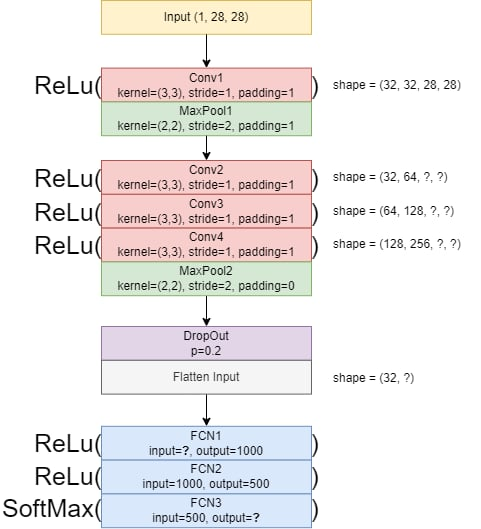

### <strong>I. Full Implementation</strong>

In [16]:
# import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

In [17]:
def calc_out(w, f, s, p):
    """
    Calculate output shape of a matrix after a convolution.
    """
    print(f'Output Shape: {(w - f + 2 * p) // s + 1}')

In [ ]:
# Conv1: k=3, s=1, p=1 on 28x28 
calc_out(28, 3, 1, 1)

# MaxPool1: k=2, s=2, p=1 on 28x28 
calc_out(28, 2, 2, 1)

# Conv2/3/4: k=3, s=1, p=1 on 15x15 
calc_out(15, 3, 1, 1)

# MaxPool2: k=2, s=2, p=0 on 15x15
calc_out(15, 2, 2, 0)

Output Shape: 28
Output Shape: 15
Output Shape: 15
Output Shape: 7


In [19]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, (3,3), 1, 1)
        self.pool1 = nn.MaxPool2d((2,2), 2, 1)

        self.conv2 = nn.Conv2d(32, 64, (3,3), 1, 1)
        self.conv3 = nn.Conv2d(64, 128, (3,3), 1, 1)
        self.conv4 = nn.Conv2d(128, 256, (3,3), 1, 1)
        self.pool2 = nn.MaxPool2d((2,2), 2)

        self.dropout = nn.Dropout(0.2)

        self.fcn1 = nn.Linear(256*7*7, 1000)
        self.fcn2 = nn.Linear(1000, 500)
        self.fcn3 = nn.Linear(500, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool2(F.relu(self.conv4(x)))

        x = self.dropout(x)
        x = x.view(-1, 256*7*7)

        x = F.relu(self.fcn1(x))
        x = F.relu(self.fcn2(x))
        x = F.softmax(self.fcn3(x), dim=1)
        return x

In [20]:
model = CNN()

In [21]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

In [22]:
count_parameters(model)

   288
    32
 18432
    64
 73728
   128
294912
   256
12544000
  1000
500000
   500
  5000
    10
______
13438350


### <strong>II. Breakdown</strong>

#### 1. **Input**

The input image has a shape of (1, 28, 28) — a single grayscale channel, 28 pixels wide and 28 pixels tall.

#### 4. **Conv1 + ReLU**

The first convolution uses a 3×3 kernel with stride 1 and padding 1, which keeps the spatial dimensions unchanged. It expands the channel count from 1 to 32, so the output shape is (32, 28, 28), exactly as shown in the diagram.

```python

conv1 = nn.Conv2d(1, 32, (3,3), 1, 1)

```

#### 3. **MaxPool1**

The first max-pooling layer uses a 2×2 kernel, stride 2, and padding 1. The diagram doesn't state the resulting size, so we calculate it: ```(28 + 2×1 − 2) / 2 + 1 = 15```. This halves the spatial dimensions down to ```(32, 15, 15)```.

```python

pool1 = nn.MaxPool2d((2,2), 2, 1)

```

#### 4. **Conv2 + ReLU**

The second convolution again uses a 3×3 kernel, stride 1, and padding 1, so it preserves the 15×15 spatial size while increasing the channels from 32 to 64, giving ```(64, 15, 15)```.

```python

conv2 = nn.Conv2d(32, 64, (3,3), 1, 1)

```

#### 5. **Conv3 + ReLU**

The third convolution follows the same same-padding pattern, increasing the channels from 64 to 128 while keeping the spatial size at 15×15, producing ```(128, 15, 15)```.

```python

conv3 = nn.Conv2d(64, 128, (3,3), 1, 1)

```

#### 6. **Conv4 + ReLU**

The fourth convolution keeps the same-padding pattern as well, increasing the channels from 128 to 256 while the spatial size stays at 15×15, giving ```(256, 15, 15)```.

```python

conv4 = nn.Conv2d(128, 256, (3,3), 1, 1) graa

```

#### 7. **MaxPool2**

The second max-pooling layer uses a 2×2 kernel, stride 2, and no padding this time. Working out the arithmetic, ```(15 + 0 − 2) / 2 + 1 = 7``` so the feature map shrinks to ```(256, 7, 7)```

```python

pool2 = nn.MaxPool2d((2,2), 2)

```

#### 8. **DropOut**

A dropout layer with ```p=0.2``` is applied next, randomly zeroing 20% of the activations during training to reduce overfitting. 

```python

dropout = nn.Dropout(0.2)

```

#### 9. **Flatten**

Before the fully connected layers can process the data, the 3-dimensional feature map needs to be flattened into a single vector per instance. Since the feature map at this point is ```256 × 7 × 7```, each instance flattens into a vector of ```12544``` values, matching the diagram's ```(32, ?)``` batch shape.

```python

x = x.view(-1, 256*7*7)

```

#### 10. **FCN1 + ReLU**

The first fully connected layer takes the flattened ```12544-length``` vector as input and projects it down to ```1000``` output features, as specified in the diagram. 

```python

fcn1 = nn.Linear(256*7*7, 1000)

```

#### 11. **FCN2 + ReLU**

The second fully connected layer takes the 1000 features from FCN1 and reduces them to 500.

```python

fcn2 = nn.Linear(1000, 500)

```

#### 12. **FCN3 + SoftMax**

The final fully connected layer takes the 500 features from FCN2 and maps them to the output classes. The diagram leaves this output size unspecified, but since this model is being trained on MNIST digits, the output should be 10 (one score per digit, 0 through 9). A softmax activation is then applied to convert these raw scores into class probabilities.

```python

fcn3 = nn.Linear(500, 10)

```

#### Summary Table

| Layer             |                      Weight |  Bias |
| ----------------- | --------------------------: | ----: |
| conv1 (1→32)      |        32 × 1 × 3 × 3 = 288 |    32 |
| conv2 (32→64)     |    64 × 32 × 3 × 3 = 18,432 |    64 |
| conv3 (64→128)    |   128 × 64 × 3 × 3 = 73,728 |   128 |
| conv4 (128→256)   | 256 × 128 × 3 × 3 = 294,912 |   256 |
| fcn1 (12544→1000) |   1000 × 12544 = 12,544,000 | 1,000 |
| fcn2 (1000→500)   |        500 × 1000 = 500,000 |   500 |
| fcn3 (500→10)     |            10 × 500 = 5,000 |    10 |
